## 10. Candidate Exogenous Feature Screening For Elastic Net

This table is an Elastic Net candidate pool, not final feature selection. EDA diagnostics such as CCF, Granger tests, VIF, missingness, and stability checks identify plausible regressors. The final Elastic Net feature set must be selected later with rolling-origin or walk-forward forecasting performance. In short: EDA screens candidate regressors; out-of-sample rolling-origin forecasting selects the final Elastic Net feature set.

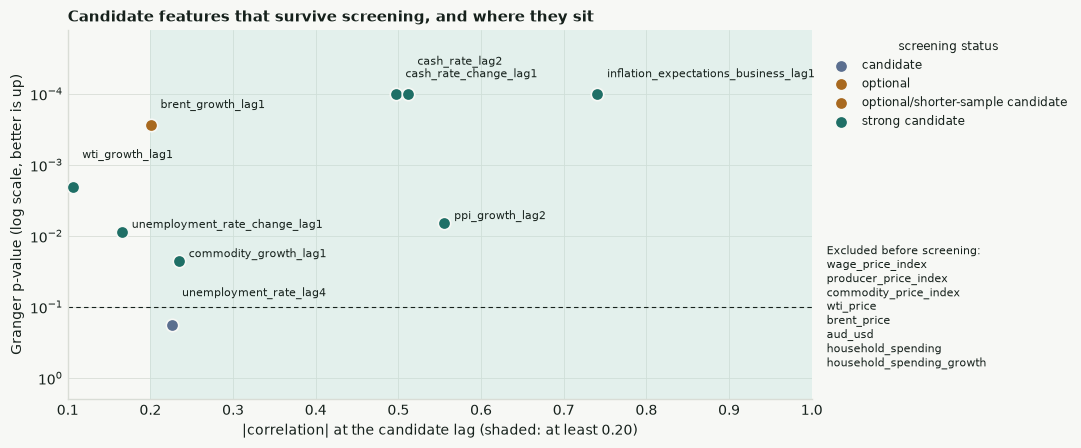

Elastic Net candidate pool from headline CPI EDA screening: unemployment_rate_lag4, brent_growth_lag1, cash_rate_change_lag1, inflation_expectations_business_lag1, cash_rate_lag2, wti_growth_lag1, ppi_growth_lag2, unemployment_rate_change_lag1, commodity_growth_lag1

These are not final feature-selection results. The modelling stage should compare a small set of nested Elastic Net feature specifications with walk-forward RMSE/MAE against seasonal-naive and SARIMA baselines, not exhaustive subset search on this small sample.

CPI-family diagnostics below are reviewed separately from ordinary exogenous macro indicators because they are alternative CPI measures or headline-minus-underlying inflation transforms.

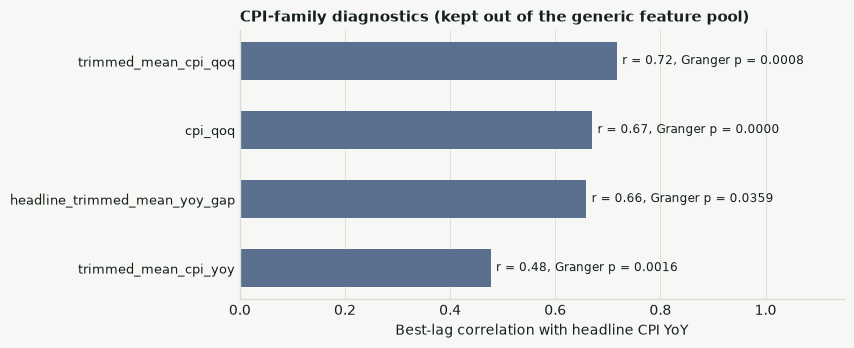

In [12]:
coverage_lookup = coverage.set_index('variable')
stationarity_lookup = stationarity.set_index('variable')


def classify_candidate(row: pd.Series) -> tuple[str, str]:
    blockers = []
    warnings = []
    signals = []

    if not row.get('has_lag_feature', False):
        blockers.append('no lagged feature engineered in this notebook/src/features.py')
    elif pd.isna(row.get('feature_lag_quarters')):
        blockers.append('no candidate lag selected after availability/sample screen')
    elif row.get('forecast_origin_safe_under_assumption') is False:
        blockers.append('unsafe under assumed publication-lag metadata')

    if pd.notna(row.get('vif')) and row.get('vif') > VIF_THRESHOLD:
        warnings.append('high VIF in primary candidate matrix')
    if row.get('late_start_reduces_estimation_sample', False):
        warnings.append('starts later than full sample; reduces estimation window')
    if row.get('substantial_missingness_warning', False):
        warnings.append('substantial missingness warning')
    if row.get('candidate_feature') in row.get('oil_alternative_features', set()):
        warnings.append('alternative oil proxy; use at most one of WTI/Brent in an Elastic Net specification')

    if pd.notna(row.get('candidate_abs_corr')) and row.get('candidate_abs_corr') >= SIGNAL_CORR_THRESHOLD:
        signals.append('candidate-lag CCF signal')
    if pd.notna(row.get('candidate_granger_p_value')) and row.get('candidate_granger_p_value') <= SIGNAL_P_THRESHOLD:
        signals.append('candidate-lag Granger screening signal')

    if blockers:
        return 'exclude', '; '.join(blockers + warnings) if warnings else '; '.join(blockers)
    if not signals:
        return 'optional', '; '.join(warnings + ['weak candidate-lag CCF/Granger screening signal']) if warnings else 'weak candidate-lag CCF/Granger screening signal'
    strong_signal = (
        pd.notna(row.get('candidate_abs_corr')) and row.get('candidate_abs_corr') >= 0.40
    ) or (
        pd.notna(row.get('candidate_granger_p_value')) and row.get('candidate_granger_p_value') <= 0.05
    )
    if strong_signal and not row.get('substantial_missingness_warning', False) and not (pd.notna(row.get('vif')) and row.get('vif') > VIF_THRESHOLD):
        return 'strong candidate', '; '.join(warnings + signals) if warnings else '; '.join(signals)
    if warnings:
        return 'optional/shorter-sample candidate', '; '.join(warnings + signals)
    return 'candidate', '; '.join(signals)


def build_target_shortlist(
    target: str,
    candidate_artifacts: dict[str, object],
    best_predictive: pd.DataFrame,
    granger_frame: pd.DataFrame,
    message_prefix: str,
    show_result: bool = True,
) -> dict[str, object]:
    candidate_diag = candidate_artifacts['candidate_feature_diagnostics']
    candidate_diag_lookup = candidate_diag.set_index('candidate_feature') if not candidate_diag.empty else pd.DataFrame()
    chosen_feature_by_base = {lag_base_name(feature): feature for feature in candidate_artifacts['candidate_features']}
    vif_frame = candidate_artifacts['vif']
    vif_lookup = vif_frame.set_index('candidate_feature')['vif'].to_dict() if not vif_frame.empty else {}
    ccf_lookup = best_predictive.set_index('variable')
    granger_lookup_frame = granger_frame.set_index('variable')
    oil_alternative_features = set(candidate_artifacts['oil_pair_decision']['alternative_oil_feature']) if not candidate_artifacts['oil_pair_decision'].empty else set()

    shortlist_rows = []
    for variable in EXTERNAL_BASE_COLS:
        chosen_feature = chosen_feature_by_base.get(variable)
        availability_row = feature_availability.loc[feature_availability['candidate_feature'] == chosen_feature].iloc[0].to_dict() if chosen_feature in set(feature_availability['candidate_feature']) else {}
        candidate_row = candidate_diag_lookup.loc[chosen_feature].to_dict() if chosen_feature in candidate_diag_lookup.index else {}
        row = {
            'target': target,
            'variable': variable,
            'candidate_feature': chosen_feature,
            'has_lag_feature': variable in lagged_feature_bases,
            'integration_order': stationarity_lookup.loc[variable, 'integration_order'] if variable in stationarity_lookup.index else None,
            'best_ccf_lag': int(ccf_lookup.loc[variable, 'lag_quarters']) if variable in ccf_lookup.index else np.nan,
            'best_ccf_corr': ccf_lookup.loc[variable, 'correlation'] if variable in ccf_lookup.index else np.nan,
            'candidate_lag': candidate_row.get('candidate_lag', np.nan),
            'candidate_corr': candidate_row.get('candidate_corr', np.nan),
            'candidate_abs_corr': candidate_row.get('candidate_abs_corr', np.nan),
            'candidate_granger_p_value': candidate_row.get('candidate_granger_p_value', np.nan),
            'min_granger_p_value': granger_lookup_frame.loc[variable, 'min_granger_p_value'] if variable in granger_lookup_frame.index else np.nan,
            'vif': vif_lookup.get(chosen_feature, np.nan),
            'assumed_min_safe_lag_quarters': availability_assumptions.set_index('variable').loc[variable, 'assumed_min_safe_lag_quarters'] if variable in set(availability_assumptions['variable']) else np.nan,
            'feature_lag_quarters': availability_row.get('feature_lag_quarters', np.nan),
            'forecast_origin_safe_under_assumption': availability_row.get('forecast_origin_safe_under_assumption', False),
            'available_observations': coverage_lookup.loc[variable, 'available_observations'] if variable in coverage_lookup.index else np.nan,
            'coverage_pct': coverage_lookup.loc[variable, 'coverage_pct'] if variable in coverage_lookup.index else np.nan,
            'missing_pct': coverage_lookup.loc[variable, 'missing_pct'] if variable in coverage_lookup.index else np.nan,
            'first_non_null': coverage_lookup.loc[variable, 'first_non_null'] if variable in coverage_lookup.index else None,
            'last_non_null': coverage_lookup.loc[variable, 'last_non_null'] if variable in coverage_lookup.index else None,
            'coverage_class': coverage_lookup.loc[variable, 'coverage_class'] if variable in coverage_lookup.index else None,
            'late_start_reduces_estimation_sample': bool(coverage_lookup.loc[variable, 'late_start_reduces_estimation_sample']) if variable in coverage_lookup.index else True,
            'substantial_missingness_warning': bool(coverage_lookup.loc[variable, 'substantial_missingness_warning']) if variable in coverage_lookup.index else True,
            'oil_alternative_features': oil_alternative_features,
        }
        row['screening_status'], row['reason'] = classify_candidate(pd.Series(row))
        row.pop('oil_alternative_features', None)
        shortlist_rows.append(row)

    shortlist = pd.DataFrame(shortlist_rows).sort_values(['screening_status', 'candidate_granger_p_value', 'candidate_abs_corr'], ascending=[True, True, False])
    strong_or_candidate_features = shortlist.loc[shortlist['screening_status'].isin(['strong candidate', 'candidate', 'optional/shorter-sample candidate']), 'candidate_feature'].dropna().tolist()
    if strong_or_candidate_features:
        message = message_prefix + ': ' + ', '.join(strong_or_candidate_features)
    else:
        message = f'No external variables passed the candidate screening checks for {target}. Revisit feature engineering before Elastic Net modelling.'

    if show_result:
        with plt.rc_context(BOOK_STYLE):
            s = shortlist.copy()
            kept = s.dropna(subset=["candidate_abs_corr"]).copy()
            dropped = s[s["candidate_abs_corr"].isna()]["variable"].tolist()
            palette = {"strong candidate": ACCENT, "candidate": BLUE, "optional": HIGHLIGHT,
                       "optional/shorter-sample candidate": HIGHLIGHT, "exclude": MUTED}
            floor = 1e-4
            fig, ax = plt.subplots(figsize=(9.6, 4.8))
            ax.axvspan(0.20, 1.0, color=ACCENT_SOFT, alpha=0.35, linewidth=0)
            ax.axhline(0.10, color=INK, linewidth=0.8, linestyle=(0, (4, 3)))
            for status, sub in kept.groupby("screening_status"):
                ax.scatter(sub["candidate_abs_corr"], sub["candidate_granger_p_value"].clip(lower=floor), s=80,
                           color=palette.get(status, MUTED), edgecolor=PAPER, linewidth=1.2, label=status, zorder=3)
            order = kept.sort_values("candidate_abs_corr").reset_index(drop=True)
            for i, r in order.iterrows():
                ax.annotate(r["candidate_feature"], (r["candidate_abs_corr"], max(r["candidate_granger_p_value"], floor)),
                            xytext=(7, 3 + 9 * (i % 3)), textcoords="offset points", fontsize=7.6)
            ax.set_yscale("log")
            ax.set_ylim(2, floor / 8)
            ax.set_xlim(0.1, 1.0)
            ax.set_xlabel("|correlation| at the candidate lag (shaded: at least 0.20)")
            ax.set_ylabel("Granger p-value (log scale, better is up)")
            ax.set_title("Candidate features that survive screening, and where they sit", loc="left", fontsize=11, fontweight="bold")
            ax.legend(frameon=False, fontsize=8.3, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="screening status",
                      title_fontsize=8.5)
            if dropped:
                ax.text(1.02, 0.42, "Excluded before screening:" + chr(10) + chr(10).join(dropped), transform=ax.transAxes,
                        ha="left", va="top", fontsize=7.8)
            plt.show()
        display(Markdown(message + '\n\nThese are not final feature-selection results. The modelling stage should compare a small set of nested Elastic Net feature specifications with walk-forward RMSE/MAE against seasonal-naive and SARIMA baselines, not exhaustive subset search on this small sample.'))

    return {
        'shortlist': shortlist,
        'chosen_feature_by_base': chosen_feature_by_base,
        'message': message,
        'strong_or_candidate_features': strong_or_candidate_features,
    }


headline_shortlist_artifacts = build_target_shortlist(
    TARGET,
    headline_candidate_artifacts,
    best_predictive_ccf,
    granger,
    'Elastic Net candidate pool from headline CPI EDA screening',
    show_result=True,
)
shortlist = headline_shortlist_artifacts['shortlist']
chosen_feature_by_base = headline_shortlist_artifacts['chosen_feature_by_base']

cpi_family_vif_lookup = cpi_family_vif.set_index('candidate_feature')['vif'].to_dict() if not cpi_family_vif.empty else {}
cpi_family_screening_rows = []
headline_ccf_lookup = best_predictive_ccf.set_index('variable')
headline_granger_lookup_frame = granger.set_index('variable')
for variable in [column for column in CPI_DIAGNOSTIC_BASE_COLS if column in df_model.columns]:
    lag_feature = 'trimmed_mean_cpi_yoy_lag1' if variable == 'trimmed_mean_cpi_yoy' else None
    diagnostic_lag = feature_lag(lag_feature) if lag_feature else int(headline_ccf_lookup.loc[variable, 'lag_quarters']) if variable in headline_ccf_lookup.index else np.nan
    row = {
        'variable': variable,
        'lag_feature_reviewed': lag_feature,
        'integration_order': stationarity_lookup.loc[variable, 'integration_order'] if variable in stationarity_lookup.index else None,
        'best_ccf_lag': int(headline_ccf_lookup.loc[variable, 'lag_quarters']) if variable in headline_ccf_lookup.index else np.nan,
        'best_ccf_corr': headline_ccf_lookup.loc[variable, 'correlation'] if variable in headline_ccf_lookup.index else np.nan,
        'diagnostic_lag': diagnostic_lag,
        'diagnostic_lag_corr': ccf_corr_at_lag(variable, diagnostic_lag) if pd.notna(diagnostic_lag) else np.nan,
        'diagnostic_lag_granger_p_value': granger_p_at_lag(variable, diagnostic_lag) if pd.notna(diagnostic_lag) else np.nan,
        'min_granger_p_value': headline_granger_lookup_frame.loc[variable, 'min_granger_p_value'] if variable in headline_granger_lookup_frame.index else np.nan,
        'vif_if_lag_feature_reviewed': cpi_family_vif_lookup.get(lag_feature, np.nan),
        'screening_note': 'CPI-family diagnostic; keep out of generic external Elastic Net feature pool pending out-of-sample tests.',
    }
    cpi_family_screening_rows.append(row)

cpi_family_screening_diagnostics = pd.DataFrame(cpi_family_screening_rows)
display(Markdown('CPI-family diagnostics below are reviewed separately from ordinary exogenous macro indicators because they are alternative CPI measures or headline-minus-underlying inflation transforms.'))
with plt.rc_context(BOOK_STYLE):
    c = cpi_family_screening_diagnostics.sort_values("best_ccf_corr").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(7.8, 0.5 * len(c) + 1.5))
    ax.barh(c.index, c["best_ccf_corr"], color=BLUE, height=0.55)
    for y, r in c.iterrows():
        ax.text(r["best_ccf_corr"] + 0.01, y, f"r = {r['best_ccf_corr']:.2f}, Granger p = {r['min_granger_p_value']:.4f}",
                va="center", fontsize=8.5)
    ax.set_yticks(c.index, c["variable"], fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel("Best-lag correlation with headline CPI YoY")
    ax.set_title("CPI-family diagnostics (kept out of the generic feature pool)", loc="left", fontsize=11, fontweight="bold")
    ax.grid(axis="y", visible=False)
    plt.show()

**Interpretation.** The headline candidate pool that survives screening (nine features
led by `inflation_expectations_business_lag1`, `ppi_growth_lag2`, and the cash-rate
lags) is a *shortlist*, not the final Elastic Net feature set; that selection still happens
by walk-forward RMSE in the modelling stage (§4.2), not by picking the best-looking EDA
numbers. The CPI-family diagnostics (`cpi_qoq`, `trimmed_mean_cpi_qoq`, the
headline-minus-trimmed-mean gap) are reviewed separately and deliberately kept out of this
pool, since they're alternative measures of the same target rather than independent external
information.